[2026-06-26 Fiddler](https://thefiddler.substack.com/p/can-you-tile-the-hexagon)
====================

Fiddler
-------

In [1]:
def hexagonal_region(n):
    return frozenset(
        [(row,col) for row in range(n) for col in range(2*(row+n)+1)]
        + [(n+row,col+1+2*row) for row in range(n) for col in range(2*(n-1-row+n)+1)])

def plot_triangle(rc,tile=False):
    (row,col) = rc
    y = sqrt(3)/2*row
    x = col/2-row/2
    if is_even(col):
        points = [(x,y),(x-1/2,y+sqrt(3)/2),(x+1/2,y+sqrt(3)/2)]
    else:
        points = [(x,y+sqrt(3)/2),(x-1/2,y),(x+1/2,y)]
    if tile:
        return polygon(points, fill=True, color=tile, axes=False)
    else:
        return polygon(points, fill=False, color="black", axes=False)

def plot_region(region, new_tiles, more_new_tiles):
    return sum([plot_triangle(rc) for rc in region]
               + [plot_triangle(rc,tile="#68a") for rc in new_tiles]
               + [plot_triangle(rc,tile="#bcf") for rc in more_new_tiles])

Arbitrarily pick a triangle with a side on the edge.  There are two ways
to cover the triangle with a tile.

With the choice on the right, the positions of three additional tiles are
determined.

I'll call the remaining region on the left octagon22, and the remaining
region on the right hexagon16.

As worked out below, there are 14 ways to tile octagon22 and 6 ways
to tile hexagon16, for a total of 20 ways.

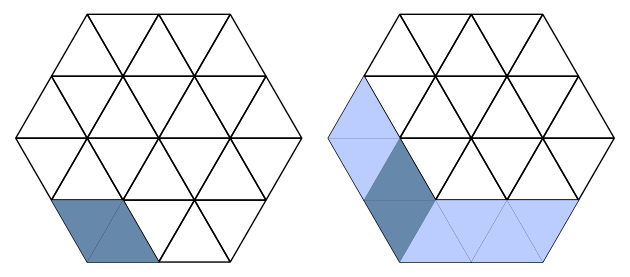

In [2]:
g = graphics_array([plot_region(hexagonal_region(2), [(0,0),(0,1)], []),
                    plot_region(hexagonal_region(2), [(0,0),(1,1)],
                                [(1,0),(2,1),(0,1),(0,2),(0,3),(0,4)])])
octagon22 = hexagonal_region(2) - set([(0,0),(0,1)])
hexagon16 = hexagonal_region(2) - set([(0,0),(1,1),(1,0),(2,1),(0,1),(0,2),(0,3),(0,4)])
g

With octagon22, two choices for the first tile lead to
nonagon18 on the left and hexagon16 on the right, which can be tiled
in 8 and 6 ways, for a total of 14 ways.

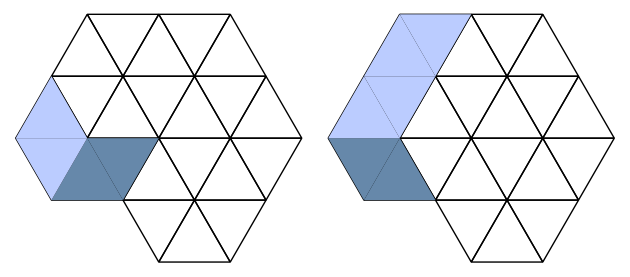

In [3]:
g = graphics_array([plot_region(octagon22,
                                [(1,1),(1,2)],
                                [(1,0),(2,1)]),
                    plot_region(octagon22,
                                [(1,1),(1,0)],
                                [(2,1),(2,2),(3,3),(3,4)])])
nonagon18 = octagon22 - set([(1,1),(1,2),(1,0),(2,1)])
g

With nonagon18, two choices for the first tile leads to
hexagon10 on the left and octagon14 on the right, which can be tiled in
3 and 5 ways, for a total of 8 ways.

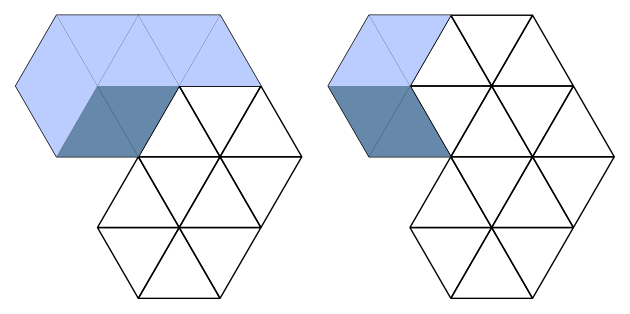

In [4]:
g = graphics_array([plot_region(nonagon18,
                                [(2,3),(2,4)],
                                [(2,2),(3,3),(3,4),(3,5),(3,6),(3,7)]),
                    plot_region(nonagon18,
                                [(2,3),(2,2)],
                                [(3,3),(3,4)])])
hexagon10 = nonagon18 - set([(2,3),(2,4),(2,2),(3,3),(3,4),(3,5),(3,6),(3,7)])
octagon14 = nonagon18 - set([(2,3),(2,2),(3,3),(3,4)])
g

With hexagon16, two choice for the first tile lead to octagon14 on the left and nothing remaining on
the right, which can be tiled in 5 and 1 ways, for a total of 6 ways.

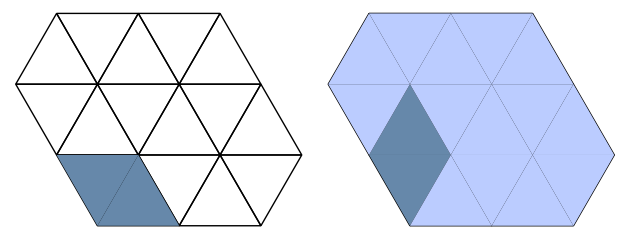

In [5]:
g = graphics_array([plot_region(hexagon16,
                                [(1,2),(1,3)],
                                []),
                    plot_region(hexagon16,
                                [(1,2),(2,3)],
                                [(2,2),(3,3),(1,3),(1,4),(1,5),(1,6),(2,4),(2,5),(2,6),(2,7),(3,4),(3,5),(3,6),(3,7)])])
g

With octagon14, two choices for the first tile lead to hexagon6 on the left and hexagon10 on the right,
which can be tiled in 2 and 3 ways, for a total of 5 ways.

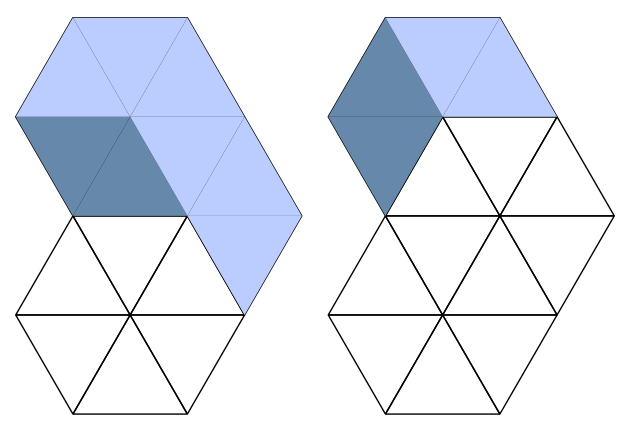

In [6]:
g = graphics_array([plot_region(octagon14,
                                [(2,4),(2,5)],
                                [(3,5),(3,6),(3,7),(2,6),(2,7),(1,6)]),
                    plot_region(octagon14,
                                [(2,4),(3,5)],
                                [(3,6),(3,7)])])
g

With hexagon10, two choices for the first tile lead to nothing on the left and hexagon6 on
the right, which can be tiled in 1 and 2 ways, for a total of 3 ways.

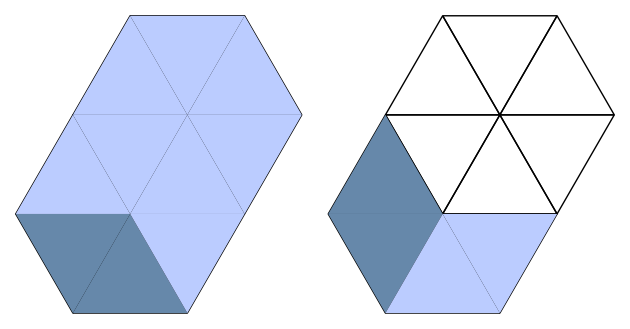

In [7]:
g = graphics_array([plot_region(hexagon10,
                                [(0,2),(0,3)],
                                [(1,3),(1,4),(1,5),(1,6),(0,4),(2,5),(2,6),(2,7)]),
                    plot_region(hexagon10,
                                [(0,2),(1,3)],
                                [(0,3),(0,4)])])
g

Extra credit
------------
Using code, I determine that there are 980 ways to tile the 54-triangle region.

In [8]:
def neighbors(rc):
    (row,col) = rc
    # in my mind, when col is even, there is one vertex at the top and a side and two vertices at the bottom
    # when col is odd, there are a side and two vertices at the top and one vertex at the bottom
    if is_even(col):
        return frozenset([(row,col-1),(row,col+1),(row+1,col+1)])
    else:
        return frozenset([(row,col-1),(row,col+1),(row-1,col-1)])

import functools

@functools.cache
def ways(region):
    if len(region) == 0:
        return 1
    for pivot in region:
        nbors = region & neighbors(pivot)
        if len(nbors) == 0:
            return 0
        if len(nbors) == 1:
            return ways(region - frozenset([pivot]) - nbors)
    for pivot in region:
        nbors = region & neighbors(pivot)
        if len(nbors) == 2:
            return sum([ways(region - frozenset([pivot,nbor])) for nbor in nbors])
    assert False

[ways(hexagonal_region(n)) for n in [1,2,3]]

[2, 20, 980]

This code is too slow to count the ways to tile a 96-triangle hexagonal region, but
maybe it would be feasible with region canonicalization.